# 4.3 距离度量

> **NOAI竞赛课程 · 模块四：数学基础（第5课时）**

---

## 本节目标

1. 欧氏距离、曼哈顿距离、明可夫斯基距离
2. 余弦相似度
3. 各距离度量的适用场景
4. Python实战：距离计算与可视化

---

## 一、欧氏距离（Euclidean Distance）

$$d_2(\mathbf{a},\mathbf{b}) = \sqrt{\sum_{i=1}^{n}(a_i-b_i)^2} = \|\mathbf{a}-\mathbf{b}\|_2$$

几何含义：两点间直线距离（$L_2$范数）。

应用：KNN、K-Means、图像比较

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体，避免中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文黑体
plt.rcParams['axes.unicode_minus'] = False    # 负号正常显示

def euclidean(a, b):
    return np.sqrt(np.sum((a-b)**2))

A = np.array([1,2], dtype=float); B = np.array([4,6], dtype=float)
print(f"A={A}, B={B}")
print(f"欧氏距离 = √[9+16] = {euclidean(A,B):.3f}")
print(f"验证: np.linalg.norm(A-B) = {np.linalg.norm(A-B):.3f}")

A=[1. 2.], B=[4. 6.]
欧氏距离 = √[9+16] = 5.000
验证: np.linalg.norm(A-B) = 5.000


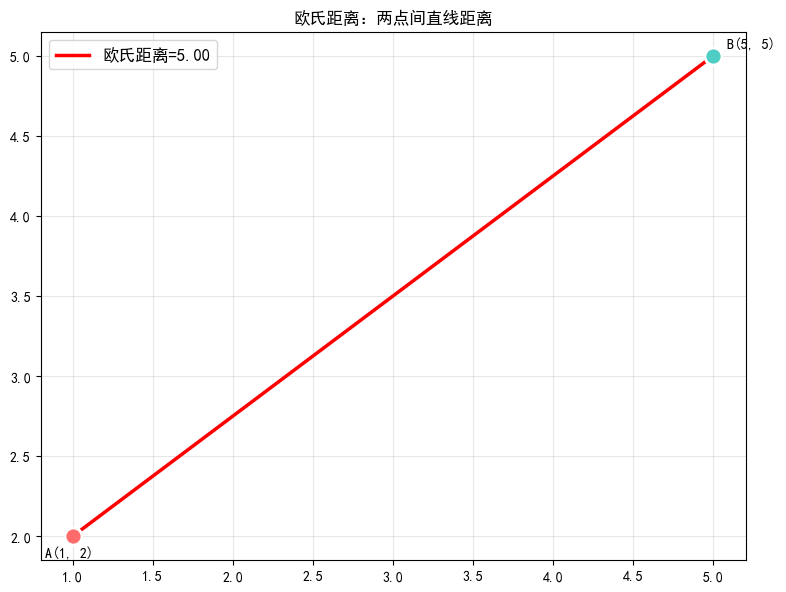

In [13]:
fig, ax = plt.subplots(figsize=(8,8))
p1, p2 = np.array([1,2]), np.array([5,5])
ax.plot([p1[0],p2[0]], [p1[1],p2[1]], 'r-', lw=2.5, label=f'欧氏距离={euclidean(p1,p2):.2f}')
ax.scatter(*p1, c='#FF6B6B', s=150, zorder=5, edgecolors='white', lw=2)
ax.scatter(*p2, c='#4ECDC4', s=150, zorder=5, edgecolors='white', lw=2)
ax.annotate(f'A{tuple(p1)}', p1, xytext=(-20,-15), textcoords='offset points', fontweight='bold')
ax.annotate(f'B{tuple(p2)}', p2, xytext=(10,5), textcoords='offset points', fontweight='bold')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=12)
ax.set_title('欧氏距离：两点间直线距离', fontweight='bold'); plt.tight_layout(); plt.show()

---

## 二、曼哈顿距离（Manhattan Distance）

$$d_1(\mathbf{a},\mathbf{b}) = \sum_{i=1}^{n}|a_i-b_i| = \|\mathbf{a}-\mathbf{b}\|_1$$

几何含义：沿坐标轴走的城市街区距离（$L_1$范数）。

应用：城市路径、L1正则化（Lasso）

In [14]:
def manhattan(a, b):
    return np.sum(np.abs(a-b))

A = np.array([1,2], dtype=float); B = np.array([4,6], dtype=float)
print(f"欧氏距离 = {euclidean(A,B):.3f}")
print(f"曼哈顿距离 = |1-4|+|2-6| = {manhattan(A,B):.3f}")
print(f"➜ 曼哈顿 ≥ 欧氏（三角不等式）")

欧氏距离 = 5.000
曼哈顿距离 = |1-4|+|2-6| = 7.000
➜ 曼哈顿 ≥ 欧氏（三角不等式）


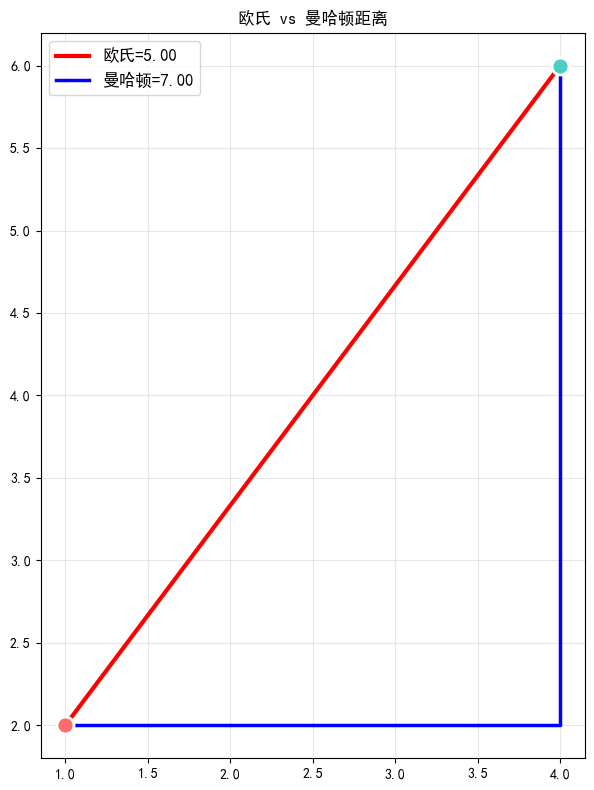

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
p1, p2 = np.array([1,2]), np.array([4,6])
ax.plot([p1[0],p2[0]], [p1[1],p2[1]], 'r-', lw=3, label=f'欧氏={euclidean(p1,p2):.2f}')
ax.plot([p1[0],p2[0],p2[0]], [p1[1],p1[1],p2[1]], 'b-', lw=2.5, label=f'曼哈顿={manhattan(p1,p2):.2f}')
ax.scatter(*p1, c='#FF6B6B', s=150, zorder=5, edgecolors='white', lw=2)
ax.scatter(*p2, c='#4ECDC4', s=150, zorder=5, edgecolors='white', lw=2)
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=12)
ax.set_title('欧氏 vs 曼哈顿距离', fontweight='bold'); plt.tight_layout(); plt.show()

---

## 三、明可夫斯基距离（Minkowski Distance）

$$d_p(\mathbf{a},\mathbf{b}) = \left(\sum_{i=1}^{n}|a_i-b_i|^p\right)^{1/p}$$

| $p$ | 名称 |
|------|------|
| 1 | 曼哈顿 |
| 2 | 欧氏 |
| $\infty$ | 切比雪夫 $\max|a_i-b_i|$ |

In [16]:
def minkowski(a, b, p):
    return np.power(np.sum(np.power(np.abs(a-b), p)), 1/p)

def chebyshev(a, b):
    return np.max(np.abs(a-b))

A = np.array([1,2], dtype=float); B = np.array([4,6], dtype=float)
for p in [1, 2, 3, 5, 10]:
    print(f"  p={p:<2}: {minkowski(A,B,p):.3f}")
print(f"  p→∞: {chebyshev(A,B):.3f}")

  p=1 : 7.000
  p=2 : 5.000
  p=3 : 4.498
  p=5 : 4.174
  p=10: 4.022
  p→∞: 4.000


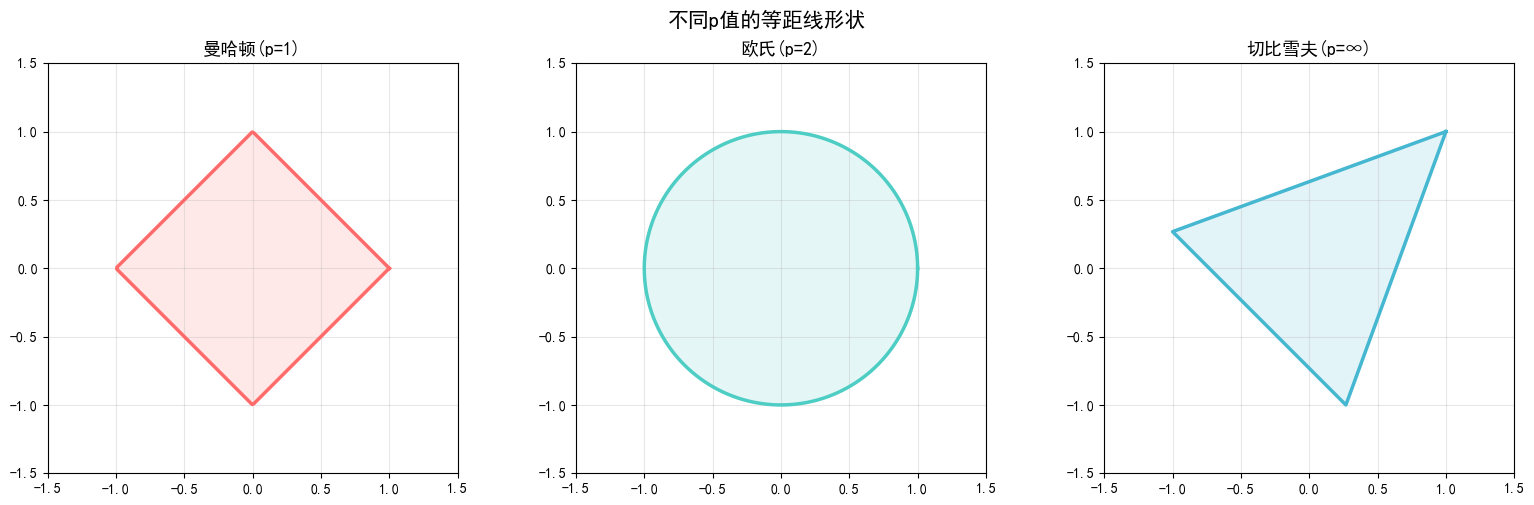

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, p, title, color in zip(axes, [1,2,np.inf], ['曼哈顿(p=1)','欧氏(p=2)','切比雪夫(p=∞)'], ['#FF6B6B','#4ECDC4','#45B7D1']):
    theta = np.linspace(0, 2*np.pi, 500)
    if p == np.inf:
        t = np.linspace(0, 2*np.pi, 4) + np.pi/4
        r = 1 / np.maximum(np.abs(np.cos(t)), np.abs(np.sin(t)))
        x, y = r*np.cos(t), r*np.sin(t)
    else:
        x = np.cos(theta) / (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p)**(1/p)
        y = np.sin(theta) / (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p)**(1/p)
    ax.plot(x, y, color=color, lw=2.5); ax.fill(x, y, alpha=0.15, color=color)
    ax.set_aspect('equal'); ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5)
    ax.grid(alpha=0.3); ax.set_title(title, fontweight='bold', fontsize=13)
plt.suptitle('不同p值的等距线形状', fontweight='bold', fontsize=15); plt.tight_layout(); plt.show()

---

## 四、余弦相似度（Cosine Similarity）

$$\cos(\mathbf{a},\mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|} \in [-1, 1]$$

| 值 | 含义 |
|----|------|
| 1 | 方向完全相同 |
| 0 | 正交（无关） |
| -1 | 方向相反 |

应用：文本相似度、推荐系统、NLP

In [18]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("余弦相似度示例:")
for va, vb, desc in [(np.array([1,0]),np.array([1,0]),'相同'),
                       (np.array([1,0]),np.array([0,1]),'正交'),
                       (np.array([1,0]),np.array([-1,0]),'相反'),
                       (np.array([1,2]),np.array([2,4]),'同方向(b=2a)')]:
    print(f"  {desc}: cos = {cosine_sim(va,vb):.3f}")

# 文本案例
doc_A = np.array([1,2,3], dtype=float)
doc_B = np.array([10,20,30], dtype=float)  # 内容相同但长度不同
print(f"\n文本A=[1,2,3] vs B=[10,20,30]:")
print(f"  欧氏距离 = {euclidean(doc_A,doc_B):.2f} (看起来远！)")
print(f"  余弦相似度 = {cosine_sim(doc_A,doc_B):.3f} (方向完全一致！)")

余弦相似度示例:
  相同: cos = 1.000
  正交: cos = 0.000
  相反: cos = -1.000
  同方向(b=2a): cos = 1.000

文本A=[1,2,3] vs B=[10,20,30]:
  欧氏距离 = 33.67 (看起来远！)
  余弦相似度 = 1.000 (方向完全一致！)


---

## 五、距离度量选择指南

| 度量 | 关注大小 | 关注方向 | 适用场景 |
|------|---------|---------|----------|
| 欧氏 | ✅ | ✅ | KNN, 图像 |
| 曼哈顿 | ✅ | ❌ | 路径, L1正则化 |
| 余弦 | ❌ | ✅ | 文本, NLP, 推荐 |

**决策原则**：关注方向相似性用余弦，关注绝对差异用欧氏/曼哈顿。

---

## 六、练习题

### 📝 练习1：计算距离

$\mathbf{a}=[3,1,4,1,5]$, $\mathbf{b}=[2,3,1,4,1]$
求欧氏、曼哈顿、余弦相似度。

In [19]:
a = np.array([3,1,4,1,5], dtype=float)
b = np.array([2,3,1,4,1], dtype=float)
print(f"欧氏距离 = {euclidean(a,b):.3f}")
print(f"曼哈顿距离 = {manhattan(a,b):.3f}")
print(f"余弦相似度 = {cosine_sim(a,b):.3f}")
print(f"明可夫斯基(p=3) = {minkowski(a,b,3):.3f}")

欧氏距离 = 6.245
曼哈顿距离 = 13.000
余弦相似度 = 0.548
明可夫斯基(p=3) = 5.027


### 📝 练习2：距离选择

场景A：比较图片像素 → 用**欧氏距离**
场景B：比较文本语义 → 用**余弦相似度**

### 📝 练习3：简化KNN

用不同距离度量进行KNN分类。

In [20]:
np.random.seed(42)
c0 = np.array([[1,1],[2,1],[1,2],[2,3],[1.5,2.5],[2,2],[3,1.5]])
c1 = np.array([[5,5],[6,5],[5,6],[6,6],[5.5,4.5],[4,5],[5,4],[6,4.5]])
X = np.vstack([c0,c1]); y = np.array([0]*len(c0)+[1]*len(c1))
test = np.array([4.0, 4.0])

def knn_dist(X, y, test, dist='euclidean', k=3):
    # 保证k为整数
    k = int(k)
    dists = []
    for i, x in enumerate(X):
        if dist=='euclidean': 
            d = np.linalg.norm(x-test)
        elif dist=='manhattan': 
            d = np.sum(np.abs(x-test))
        elif dist=='cosine': 
            d = 1 - cosine_sim(x, test)
        else:
            raise ValueError(f"未知距离: {dist}")
        dists.append((d, y[i]))
    dists.sort()
    neighbors = [d[1] for d in dists[:k]]
    return max(set(neighbors), key=neighbors.count)

for d in ['euclidean','manhattan','cosine']:
    print(f"{d}: 预测={knn_dist(X, y, test, dist=d)}")

euclidean: 预测=1
manhattan: 预测=1
cosine: 预测=0


---

## 📌 本节要点

1. 欧氏距离 = $L_2$范数，最常用
2. 曼哈顿 = $L_1$范数，适用于网格路径
3. 明可夫斯基是推广，参数$p$控制特性
4. 余弦相似度衡量方向一致性，不受向量长度影响
5. 选距离度量：关注大小→欧氏/曼哈顿，关注方向→余弦

🚀 **下一节**：[4.4 线性与非线性](./4.4_线性与非线性.ipynb)